In [7]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

In [75]:
all_df = pd.read_csv('results/tables/combined_wbet_water_year.csv')
wy_counts = all_df.loc[all_df.water_year>2015][['huc8','water_year']].groupby('huc8').count()
huc8s_filtered = wy_counts.loc[wy_counts.water_year>=5].index.to_list()
filtered_df = all_df.loc[all_df.water_year>2015][all_df['huc8'].isin(huc8s_filtered)]

/var/folders/xf/b124_hpd62s6q61gr4dvlkyr0000gn/T/ipykernel_86816/3574747679.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = all_df.loc[all_df.water_year>2015][all_df['huc8'].isin(huc8s_filtered)]


In [76]:
lu_df = pd.read_csv('data/ancillary/huc8_cdl_landuse_fractions_2023.csv')
elev_df = pd.read_csv('data/ancillary/huc8_elevation_stats.csv')

In [77]:
filtered_df.columns

Index(['huc8', 'water_year', 'AgEra-5_precipitation_mm',
       'prism_precipitation_mm', 'rdpa_precipitation_mm',
       'nclimgrid_precipitation_mm', 'gridmet_precipitation_mm',
       'chirps_precipitation_mm', 'ensemble_et_mm', 'disalexi_et_mm',
       'eemetric_et_mm', 'ptjpl_et_mm', 'ssebop_et_mm', 'geesebal_et_mm',
       'q_mm', 'wbet_AgEra-5_mm', 'wbet_prism_mm', 'wbet_rdpa_mm',
       'wbet_nclimgrid_mm', 'wbet_gridmet_mm', 'wbet_chirps_mm'],
      dtype='object')

In [78]:

wbet_cols = filtered_df.columns[filtered_df.columns.str.startswith("wbet_")]
et_cols = filtered_df.columns[filtered_df.columns.str.endswith("_et_mm")]
pr_cols = filtered_df.columns[filtered_df.columns.str.endswith("_precipitation_mm")]

filtered_df["wbet_mean"] = filtered_df[wbet_cols].mean(axis=1)
filtered_df["wbet_std"] = filtered_df[wbet_cols].std(axis=1)
filtered_df["et_std"] = filtered_df[et_cols].std(axis=1)
filtered_df["pr_mean"] = filtered_df[pr_cols].mean(axis=1)
filtered_df["pr_std"] = filtered_df[pr_cols].std(axis=1)
filtered_df["pr_cov"] = filtered_df['pr_std']/filtered_df['pr_mean']

filter_df_mean = filtered_df.groupby('huc8').mean()

Text(0, 0.5, 'OpenET Ensemble ET (mm)')

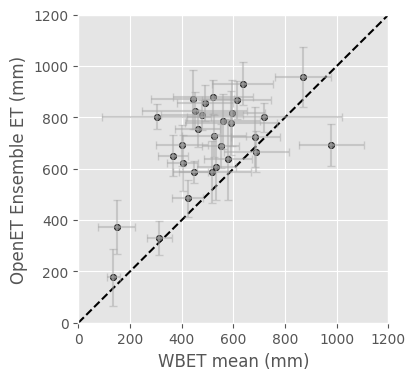

In [79]:
plt.style.use('ggplot')
fig, ax1 = plt.subplots(1,1, figsize = (4,4))
ones = np.arange(0,1300,50)

plt.plot(ones,ones, linestyle = '--',color='k')
ax1.errorbar(
    x=filter_df_mean["wbet_mean"],
    y=filter_df_mean["ensemble_et_mm"],
    xerr=filter_df_mean["wbet_std"],
    yerr=filter_df_mean["et_std"],
    fmt=".",
    linestyle="none",
    capsize=3,
    alpha=0.5,
    color='darkgray'
)
filter_df_mean.plot.scatter(x='wbet_mean',y='ensemble_et_mm',color='k',ax=ax1)

ax1.set_xlim(0, 1200)
ax1.set_ylim(0, 1200)
ax1.set_xlabel("WBET mean (mm)")
ax1.set_ylabel("OpenET Ensemble ET (mm)")

In [80]:
df_match1 = filter_df_mean.join(
    elev_df.set_index("HUC8_id"),
    how="inner")

df_match2 = df_match1.join(
    lu_df.set_index("HUC8_id"),
    how="inner")


In [81]:
df_match2.columns

df_match2['q_pr_ratio']=df_match2['q_mm']/df_match2['pr_mean']

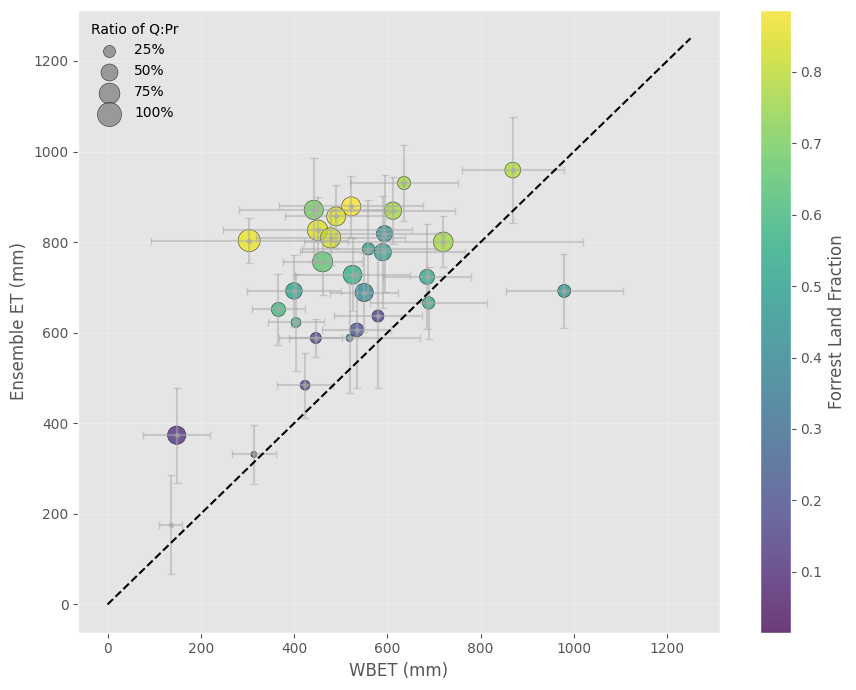

In [88]:
df = df_match2.copy()
import matplotlib.pyplot as plt

# Adjust this value to control the maximum marker size
size_scale = 300

fig, ax = plt.subplots(figsize=(9, 7))

ax.errorbar(
    x=df["wbet_mean"],
    y=df["ensemble_et_mm"],
    xerr=df["wbet_std"],
    yerr=df["et_std"],
    fmt=".",
    linestyle="none",
    capsize=3,
    alpha=0.5,
    color='darkgray'
)

scatter = ax.scatter(
    df["wbet_mean"],
    df["ensemble_et_mm"],  # Replace if the actual column name differs
    s=df["q_pr_ratio"].clip(0, 1) * size_scale,
    c=df["forrest_fraction"],
    cmap="viridis",
    alpha=0.75,
    edgecolors="black",
    linewidths=0.4
)
ax.plot(ones,ones,linestyle='--',color='k')

ax.set_xlabel("WBET (mm)")
ax.set_ylabel("Ensemble ET (mm)")

colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("Forrest Land Fraction")

# Example marker-size legend
fractions = [0.25, 0.50, 0.75, 1.00]

size_handles = [
    ax.scatter(
        [],
        [],
        s=fraction * size_scale,
        color="gray",
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
        label=f"{fraction:.0%}"
    )
    for fraction in fractions
]

ax.legend(
    handles=size_handles,
    title="Ratio of Q:Pr",
    loc="best",
    frameon=False
)

ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

In [54]:
### Join to shapefile

In [55]:
import geopandas as gpd

In [109]:
gdf = gpd.read_file('data/geo/study_area.shp')
gdf["study_ar_4"] = (
    gdf["study_ar_4"]
    .astype("string")
    .str.strip()
    .str.zfill(8)
)
gdf["study_ar_4"] = gdf.study_ar_4.astype('int')


In [120]:

gdf2=gdf.merge(df_join, right_on="index", left_on='study_ar_4', how="inner")

In [126]:
gdf.to_file('data/geo/huc8_wbet.shp')